In [1]:
import numpy as np
import pandas as pd

In [2]:
df=pd.read_csv("E:\data\data_set\Order_Tablestatestics.csv")

In [3]:
df

,Unnamed: 0,Customer_ID,Age,Monthly_Income,Order_Value,Orders_Per_Month,Discount_Percentage,Delivery_Time_Days
0,0,1102,33,42505.468953,2713.289625,5,6.526358,1.398059
1,1,1435,42,49081.559372,3911.843373,1,1.778820,3.272074
2,2,1860,32,64929.355993,1813.401346,5,9.257799,3.507662
3,3,1270,41,41326.697501,3279.828214,2,13.610320,6.636292
4,4,1106,19,66699.084691,4776.384497,3,5.193985,7.334388
...,...,...,...,...,...,...,...,...
4995,4995,1289,26,24051.414539,3071.836870,3,14.263375,9.806655
4996,4996,1294,23,53217.928542,3210.935476,0,9.494472,1.181611
4997,4997,1450,20,43383.122012,3416.314100,6,8.815458,6.021934
4998,4998,1903,39,27439.535148,2987.315893,4,1.620958,9.091445


# Measures of Central Tendency
- Q1: Find mean, median and mode of:
  - Order_Value
    - Monthly_Income
     - Delivery_Time_Days
  - let us know is there any skewness and what type it is?

  -  Is our revenue driven by few high spenders or majority moderate spenders?
        

# order value central tendency

In [4]:
mean_order=df['Order_Value'].mean()
mean_order

np.float64(3012.348958149026)

In [5]:
medianorder=df['Order_Value'].median()
medianorder

3030.11426040493

In [6]:
modeorder=df['Order_Value'].mode()
modeorder[0]

np.float64(-251.6825149875117)

# central tendency of montly_income

In [7]:
meanmi=df['Monthly_Income'].mean()
meanmi

np.float64(49931.22187155054)

In [8]:
medianmi=df['Monthly_Income'].median()
medianmi

49782.40103194001

In [9]:
modemi=df['Monthly_Income'].mode()
modemi[0]

np.float64(-6361.529818887786)

# central tendency of delivery-timedays

In [10]:
meandel=df['Delivery_Time_Days'].mean()
meandel

np.float64(5.027623226164948)

In [11]:
mediandel=df['Delivery_Time_Days'].median()
mediandel

5.025744012268435

In [12]:
modedel=df['Delivery_Time_Days'].mode()
modedel[0]

np.float64(-3.5907819681360102)

# skewness

In [13]:
df['Order_Value'].skew()

np.float64(-0.07481573158939175)

### the skewness value is -0.074 which is less than -0.5 means the skewness in data is left skew
### the revenue driven by majority of moderate spenders

# Measures of Dispersion
- Q2: Calculate:
- Variance
- Standard Deviation
- IQR
- MAD
- 25th, 50th, 75th percentile
For Order_Value.
- If SD is high:
- Is revenue predictable?
- Are customers consistent?
If IQR is wide:
- Are customers segmented naturally?

# measure of dispersion on Order_Value

# Variance

In [14]:
var=sum((df['Order_Value']-mean_order)**2)/df.shape[0]
var

645633.8191539816

In [15]:
funvar=df['Order_Value'].var()
funvar

645762.9717483323

# standard deviation

In [16]:
std=np.sqrt(var)
std

np.float64(803.5134218878871)

In [17]:
funstd=df['Order_Value'].std()
funstd

803.5937852847869

# IQR

In [18]:
quartile1=df['Order_Value'].quantile(0.25)
quartile3=df['Order_Value'].quantile(0.75)
quartile2=df['Order_Value'].quantile(0.50)

In [49]:
iqr=quartile3-quartile1
iqr

np.float64(1100.5304973266775)

In [50]:
lowerlimit=quartile1-iqr
lowerlimit

np.float64(1363.937179830235)

In [51]:
upperlimit=quartile3+iqr
upperlimit

np.float64(4665.528671810267)

<Axes: >

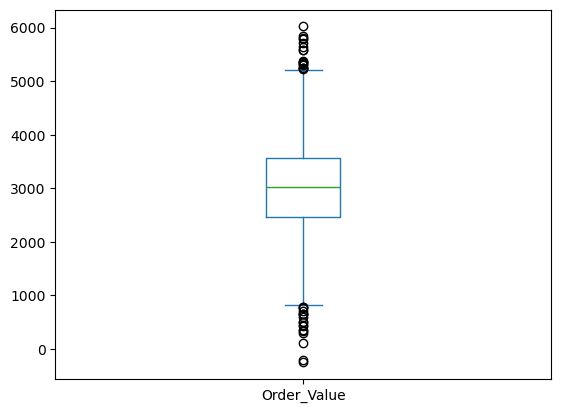

In [22]:
df['Order_Value'].plot(kind='box')

# MAD

In [23]:
mad=sum(df['Order_Value']-mean_order)/df.shape[0]
mad

9.868017514236271e-14

In [24]:
df.shape[0]

5000

# mean absolute Deviation 9.86

In [25]:
std

np.float64(803.5134218878871)

In [26]:
mean_order

np.float64(3012.348958149026)

### If Standard Deviation is high then revenue is unpredictable
### if standard Deviation is high then customers are not consistent

In [ ]:
#### if iqr is wide its not mean that are customers segmented natuarally


# Q3: Explore the Age column and
-  Which age group has highest spending variability?
-  Which group is most stable?

In [33]:
df['AgeGroup'] = pd.cut(df['Age'], bins=5, right=True)
df['AgeGroup'].unique()

[(26.8, 40.2], (40.2, 53.6], (13.4, 26.8], (53.6, 67.0], (-0.067, 13.4]]
Categories (5, interval[float64, right]): [(-0.067, 13.4] < (13.4, 26.8] < (26.8, 40.2] < (40.2, 53.6] < (53.6, 67.0]]

In [37]:
group_stats = df.groupby('AgeGroup')['Order_Value'].agg(['count', 'mean', 'std'])
print(group_stats)

                count         mean         std
AgeGroup                                      
(-0.067, 13.4]     94  3019.929072  735.241821
(13.4, 26.8]      994  3013.180145  788.653074
(26.8, 40.2]     2578  3004.632083  811.274075
(40.2, 53.6]     1194  3033.427899  799.733186
(53.6, 67.0]      140  2963.685509  848.824740


C:\Users\USER\AppData\Local\Temp\ipykernel_8340\3450516652.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_stats = df.groupby('AgeGroup')['Order_Value'].agg(['count', 'mean', 'std'])


In [39]:
def iqr(x):
    return x.quantile(0.75) - x.quantile(0.25)

group_iqr = df.groupby('AgeGroup')['Order_Value'].agg(iqr=iqr, mean='mean', count='count')
print(group_iqr)


                        iqr         mean  count
AgeGroup                                       
(-0.067, 13.4]  1124.321115  3019.929072     94
(13.4, 26.8]    1053.125780  3013.180145    994
(26.8, 40.2]    1110.904450  3004.632083   2578
(40.2, 53.6]    1110.890716  3033.427899   1194
(53.6, 67.0]    1232.662563  2963.685509    140


C:\Users\USER\AppData\Local\Temp\ipykernel_8340\2387690997.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_iqr = df.groupby('AgeGroup')['Order_Value'].agg(iqr=iqr, mean='mean', count='count')


### Age group 53-67 is has highest spending variability
### Age group 13-26 is most stable 

# Q4: Check for outlier in order value and
-  How many high spenders exist?
-  Should we create VIP category?

In [46]:
outliers=df[(df['Order_Value']>upperlimit) + (df['Order_Value']<lowerlimit)]
outliers

,Unnamed: 0,Customer_ID,Age,Monthly_Income,Order_Value,Orders_Per_Month,Discount_Percentage,Delivery_Time_Days,AgeGroup
2,2,1860,32,64929.355993,1813.401346,5,9.257799,3.507662,"(26.8, 40.2]"
4,4,1106,19,66699.084691,4776.384497,3,5.193985,7.334388,"(13.4, 26.8]"
9,9,1121,47,42515.733144,4134.049779,4,29.710745,9.324160,"(40.2, 53.6]"
18,18,1663,23,50785.443458,4196.931621,6,35.449806,5.937303,"(13.4, 26.8]"
31,31,1160,25,68787.435937,1681.690485,5,6.359050,6.153475,"(13.4, 26.8]"
...,...,...,...,...,...,...,...,...,...
4954,4954,1941,45,11644.425525,4218.157579,4,21.410595,5.520166,"(40.2, 53.6]"
4979,4979,1656,54,57511.225490,1475.023455,5,39.921291,2.407402,"(53.6, 67.0]"
4986,4986,1187,37,80545.212720,601.434273,3,29.883236,6.998358,"(26.8, 40.2]"
4988,4988,1449,27,39519.545971,5213.197991,3,15.750965,5.942182,"(26.8, 40.2]"


# high spenders

In [48]:
high_spenders= df[df['Order_Value']>upperlimit]
high_spenders.shape[0]

368

# VIP Category
- Yes we have to create vip category with some specail offers
- there is total 368 high spenders exits

# Q5: Also give your business suggestion from each descriptive measure?
- mean
   -  the mean order value is around 3000 we can estimate we can get 3000-3500 orders 
      - The customers montly income around 50000 we can estimate price according to that
      - The mean delivery time is 5 days we can able to give within 5-6 days delivery policy
- Median
  - the median is not much deviate from the mean we also assuming all metrics according to the that
- mode
  - the mode is in negitive we have to identify the trend of the customers and order values
      - we can also identify the which product is in demand
- Variance
  - The variance is very high which tells us most of the customers we have high side
- Standard deviation
  - standard deviation around to 850 which is acceptable
      - The std we can plan our bussiness which time we have more orders or less
- outliers
  - there is outliers we can seperate the vip customers and default customers

- IQR
  - we have less no of average spenders we plan our bussiness according to that